## Bitcoin Price Prediction using NeuralForecast
- Data Description
- Forecasting Models: NBEATS, NHITS, (Informer, Autoformer, FEDformer), PatchTST

In [1]:
!pip install neuralforecast
!pip install yfinance
!pip install -U ipywidgets

import warnings
warnings.filterwarnings("ignore")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 257.7/257.7 kB 22.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 285.8/285.8 kB 23.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 823.1/823.1 kB 31.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.4/68.4 MB 12.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 96.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 76.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 62.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 13.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [2]:
# Data impots
import yfinance as yf
import pandas as pd
import numpy as np

# Neural Network Forecast imports
from neuralforecast import NeuralForecast
from neuralforecast.models import NBEATS, NHITS, Informer, Autoformer, FEDformer, PatchTST

# Visualization Imports
from plotly.subplots import make_subplots
import plotly.graph_objects as go
import plotly.express as px
import plotly.io as pio
import scipy.stats as stats
import seaborn as sns
import matplotlib.pyplot as plt

pio.templates.default = "plotly_dark"

In [5]:
# Target stock & columns for modeling
SYMBOL = "BTC-USD"
columns = ['open', 'high', 'low', 'close', 'volume']

ticker = yf.Ticker(SYMBOL)

df = ticker.history(start="2024-01-01", end="2025-04-30").reset_index()

In [6]:
def plot_candlestick(df, name='Stock', rolling_avg=[20, 50, 200], fig_size=(1100, 700)):
    fig = go.Figure()

    # Candlestick chart
    fig.add_trace(go.Candlestick(
        x=df['Date'],
        open=df['Open'],
        high=df['High'],
        low=df['Low'],
        close=df['Close'],
        name=name
    ))

    # Rolling Averages
    for avg in rolling_avg:
        df[f'Rolling_{avg}'] = df['Close'].rolling(window=avg).mean()
        fig.add_trace(go.Scatter(
            x=df['Date'],
            y=df[f'Rolling_{avg}'],
            mode='lines',
            name=f'{avg}-Day Rolling Avg'
        ))

    # Layout customization
    fig.update_layout(
        title=f'{name} Candlestick Chart',
        xaxis_title='Date',
        yaxis_title='Price',
        width=fig_size[0],
        height=fig_size[1],
        xaxis_rangeslider_visible=False
    )

    fig.show()

In [7]:
plot_candlestick(
    df,
    name=SYMBOL,
    rolling_avg=[20, 50, 200],
    fig_size=(1100, 700)
)

In [8]:
df['Percent_Change'] = df['Close'].pct_change() * 100
#df['Percent_Change'].fillna(0, inplace=True)

In [9]:
import plotly.subplots as sp

fig = sp.make_subplots(
    rows=2, cols=1,
    subplot_titles=(f"Percent Change {SYMBOL}",
                    f"Volume {SYMBOL}"),
    shared_xaxes=True,
    vertical_spacing=0.1,
    horizontal_spacing=0.1,
)

fig.add_trace(go.Scatter(
    x=df.iloc[:, 0],  # 첫 번째 열을 x축으로 사용
    y=df['Percent_Change'],
    mode='lines',
    name='Percent Change',
    line=dict(color='orange')
), row=1, col=1)

fig.add_trace(go.Bar(
    x=df.iloc[:, 0],  # 첫 번째 열을 x축으로 사용
    y=df['Volume'],
    name='Volume',
), row=2, col=1)

fig.update_layout(
    title="Stock Percent Change & Volume Analysis",
    xaxis_title="Date",
    yaxis_title="Percent Change (%)",
    xaxis_rangeslider_visible=False,
    width=1100,
    height=700,
    showlegend=True,
)

fig.show()

In [10]:
df = ticker.history(start="2024-01-01", end="2025-04-30").reset_index()
#df = pd.read_csv('btc.csv')

df = df.copy()
df.rename(columns={df.columns[0]: 'ds'}, inplace=True)  # 첫 번째 열은 'ds'로 바꿈
df['ds'] = pd.to_datetime(df['ds'])
df['y'] = df['Close']  # 타깃 열을 'y'로 설정

# NeuralForecast는 시계열별 고유 식별자 필요 ('unique_id')
df['unique_id'] = SYMBOL

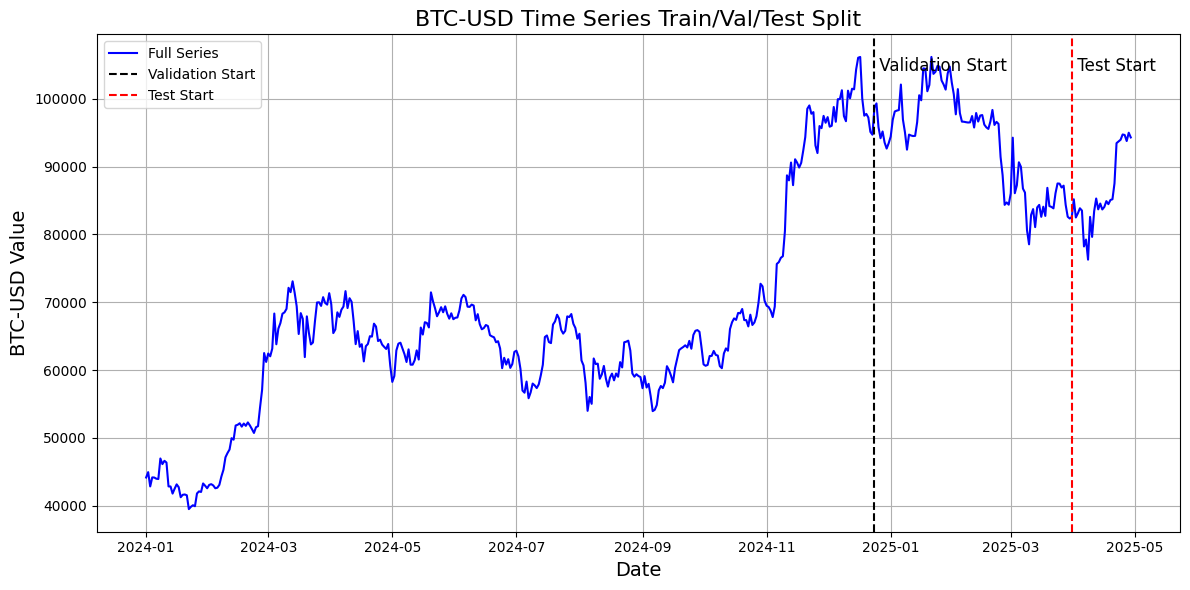

In [11]:
# 전체 시계열 길이 기준 분할 비율 설정
n_time = len(df['ds'].unique())
val_size = int(n_time * 0.2)
test_size = 30
train_size = n_time - val_size - test_size

# 특정 종목 선택
u_id = SYMBOL
df_u = df[df['unique_id'] == u_id].copy().reset_index(drop=True)

# 분할 지점 정의
x_val = df_u['ds'].iloc[train_size]
x_test = df_u['ds'].iloc[train_size + val_size]

# 시각화용 데이터
x_plot = df_u['ds']
y_plot = df_u['y'].values

# 시각화
fig = plt.figure(figsize=(12, 6))
plt.plot(x_plot, y_plot, label='Full Series', color='blue')

# 분할 지점 시각화
plt.axvline(x_val, color='black', linestyle='--', label='Validation Start')
plt.axvline(x_test, color='red', linestyle='--', label='Test Start')

# 텍스트 표시
plt.text(x_val, max(y_plot), ' Validation Start', verticalalignment='top', fontsize=12)
plt.text(x_test, max(y_plot), ' Test Start', verticalalignment='top', fontsize=12)

# 라벨 및 스타일
plt.xlabel('Date', fontsize=14)
plt.ylabel(f'{u_id} Value', fontsize=14)
plt.title(f'{u_id} Time Series Train/Val/Test Split', fontsize=16)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

In [12]:
Y_train = df[df['ds'] < x_test].reset_index(drop=True)
Y_val = df[(df['ds'] >= x_val) & (df['ds'] < x_test)].reset_index(drop=True)
Y_test = df[df['ds'] >= x_test].reset_index(drop=True)

In [13]:
# 예측 설정
horizon = 30         # 미래 30일 예측
input_size = 60      # 과거 60일 사용
freq = 'D'           # 일 단위 주기

# 모델 정의
models = [
    ('NBEATS', NBEATS(input_size=input_size, h=horizon, max_steps=100, batch_size=32, random_seed=0, val_check_steps=10, early_stop_patience_steps=5)),
    ('NHITS', NHITS(input_size=input_size, h=horizon, max_steps=100, batch_size=32, random_seed=0, val_check_steps=10, early_stop_patience_steps=5)),
    #('Informer', Informer(input_size=input_size, h=horizon, max_steps=100, batch_size=32, random_seed=0, val_check_steps=10, early_stop_patience_steps=5)),
    #('Autoformer', Autoformer(input_size=input_size, h=horizon, max_steps=100, batch_size=32, random_seed=0, val_check_steps=10, early_stop_patience_steps=5)),
    #('FEDformer', FEDformer(input_size=input_size, h=horizon, max_steps=100, batch_size=32, random_seed=0, val_check_steps=10, early_stop_patience_steps=5)),
    ('PatchTST', PatchTST(input_size=input_size, h=horizon, max_steps=100, batch_size=32, random_seed=0, val_check_steps=10, early_stop_patience_steps=5)),
]

# 개별 모델 학습 및 결과 저장
forecasts = []
for name, model in models:
    print(f"\n🔧 Training model: {name}")
    nf = NeuralForecast(models=[model], freq=freq)
    nf.fit(df=Y_train, val_size=len(Y_val))
    pred = nf.predict()
    forecasts.append(pred.rename(columns={name: name}))

INFO:lightning_fabric.utilities.seed:Seed set to 0
INFO:lightning_fabric.utilities.seed:Seed set to 0
INFO:lightning_fabric.utilities.seed:Seed set to 0
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs



🔧 Training model: NBEATS


INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:pytorch_lightning.callbacks.model_summary:
  | Name         | Type          | Params | Mode 
-------------------------------------------------------
0 | loss         | MAE           | 0      | train
1 | padder_train | ConstantPad1d | 0      | train
2 | scaler       | TemporalNorm  | 0      | train
3 | blocks       | ModuleList    | 2.6 M  | train
-------------------------------------------------------
2.6 M     Trainable params
5.5 K     Non-trainable params
2.6 M     Total params
10.287    Total estimated model params size (MB)
31        Modules in train mode
0         Modules in eval mode


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:Trainer already configured with model summary callbacks: [<class 'pytorch_lightning.callbacks.model_summary.ModelSummary'>]. Skipping setting a default `ModelSummary` callback.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Predicting: |          | 0/? [00:00<?, ?it/s]

In [14]:
Y_hat = forecasts[0]

for forecast in forecasts[1:]:
    Y_hat = Y_hat.merge(forecast, on='ds', how='outer')

Y_hat = Y_hat[['ds', 'NBEATS', 'NHITS', 'PatchTST']]
Y_hat['ds'] = list(Y_test['ds'])
Y_hat

,ds,NBEATS,NHITS,PatchTST
0,2025-03-31 00:00:00+00:00,81737.234375,81822.382812,83881.085938
1,2025-04-01 00:00:00+00:00,82333.242188,82045.648438,84097.632812
2,2025-04-02 00:00:00+00:00,81374.921875,82154.953125,82823.015625
3,2025-04-03 00:00:00+00:00,83108.789062,81570.882812,83874.203125
4,2025-04-04 00:00:00+00:00,82875.671875,81911.546875,86210.593750
5,2025-04-05 00:00:00+00:00,83036.265625,81532.734375,86724.343750
6,2025-04-06 00:00:00+00:00,83508.562500,81390.531250,86342.531250
7,2025-04-07 00:00:00+00:00,82298.960938,81350.367188,85959.078125
8,2025-04-08 00:00:00+00:00,83553.539062,81535.750000,85300.695312
9,2025-04-09 00:00:00+00:00,83569.976562,81767.015625,86254.093750


In [15]:
# 예측 결과와 실제 데이터를 결합하여 출력
#display(pd.concat([Y_test['y'], Y_hat], axis=1)[['ds', 'NBEATS', 'NHITS', 'y']])

# Traces for each line (train, test, predictions)
trace_train = go.Scatter(x=Y_train['ds'], y=Y_train['y'], line=dict(color='blue'), name='Close Train')
trace_test = go.Scatter(x=Y_test['ds'], y=Y_test['y'], mode='lines', line=dict(color='red'), name='Close Test')


model_traces = []
color_map = {
    'NBEATS': 'cyan',
    'NHITS': 'green',
    # 'Informer': 'magenta',
    # 'Autoformer': 'purple',
    # 'FEDformer': 'brown',
    'PatchTST': 'orange'
}

for col in Y_hat.columns:
    if col not in ['ds']:
        color = color_map.get(col, None)
        trace = go.Scatter(x=Y_hat['ds'], y=Y_hat[col], mode='lines',
                           line=dict(color=color) if color else None,
                           name=f'{col} Pred')
        model_traces.append(trace)

layout = go.Layout(
    title='Prediction Comparison',
    xaxis=dict(title='Date'),
    yaxis=dict(title=f'{u_id} Value'),
    showlegend=True,
    legend=dict(x=0.02, y=0.98)
)

# x축 자동 범위 설정 (test 구간 기준)
start_date = Y_train['ds'].min()
end_date = Y_test['ds'].max()

fig = go.Figure(data=[trace_train, trace_test] + model_traces, layout=layout)
fig.update_xaxes(range=[start_date, end_date])
fig.show()


### References
- https://nixtlaverse.nixtla.io/neuralforecast/docs/getting-started/introduction.html
- https://nixtlaverse.nixtla.io/neuralforecast/docs/tutorials/longhorizon_transformers.html
- https://www.kaggle.com/code/guslovesmath/amazing-nvda-forecasting-neuralforecast